In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carica gli edifici
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

# Rimuoviamo gli anni non validi
gdf_clean = gdf[gdf['Bouwjaar'] > 1500].copy()

print(f"Edifici totali: {len(gdf)}")
print(f"Edifici con anno valido: {len(gdf_clean)}")
print(f"Anno più antico: {gdf_clean['Bouwjaar'].min()}")
print(f"Anno più recente: {gdf_clean['Bouwjaar'].max()}")

Edifici totali: 44748
Edifici con anno valido: 44504
Anno più antico: 1515
Anno più recente: 2025


In [2]:
# Raggruppiamo per decennio
gdf_clean['Decennio'] = (gdf_clean['Bouwjaar'] // 10) * 10

edifici_per_decennio = gdf_clean.groupby('Decennio').size().reset_index()
edifici_per_decennio.columns = ['Decennio', 'Nuovi_edifici']

# Calcoliamo anche il totale cumulativo
edifici_per_decennio['Totale_cumulativo'] = edifici_per_decennio['Nuovi_edifici'].cumsum()

print(edifici_per_decennio.head(20))

    Decennio  Nuovi_edifici  Totale_cumulativo
0       1510              2                  2
1       1550              6                  8
2       1560              5                 13
3       1570              3                 16
4       1580              4                 20
5       1590              2                 22
6       1600             26                 48
7       1610             60                108
8       1620            119                227
9       1630             67                294
10      1640             69                363
11      1650            200                563
12      1660            122                685
13      1670            194                879
14      1680            170               1049
15      1690            173               1222
16      1700            209               1431
17      1710            299               1730
18      1720            427               2157
19      1730            438               2595


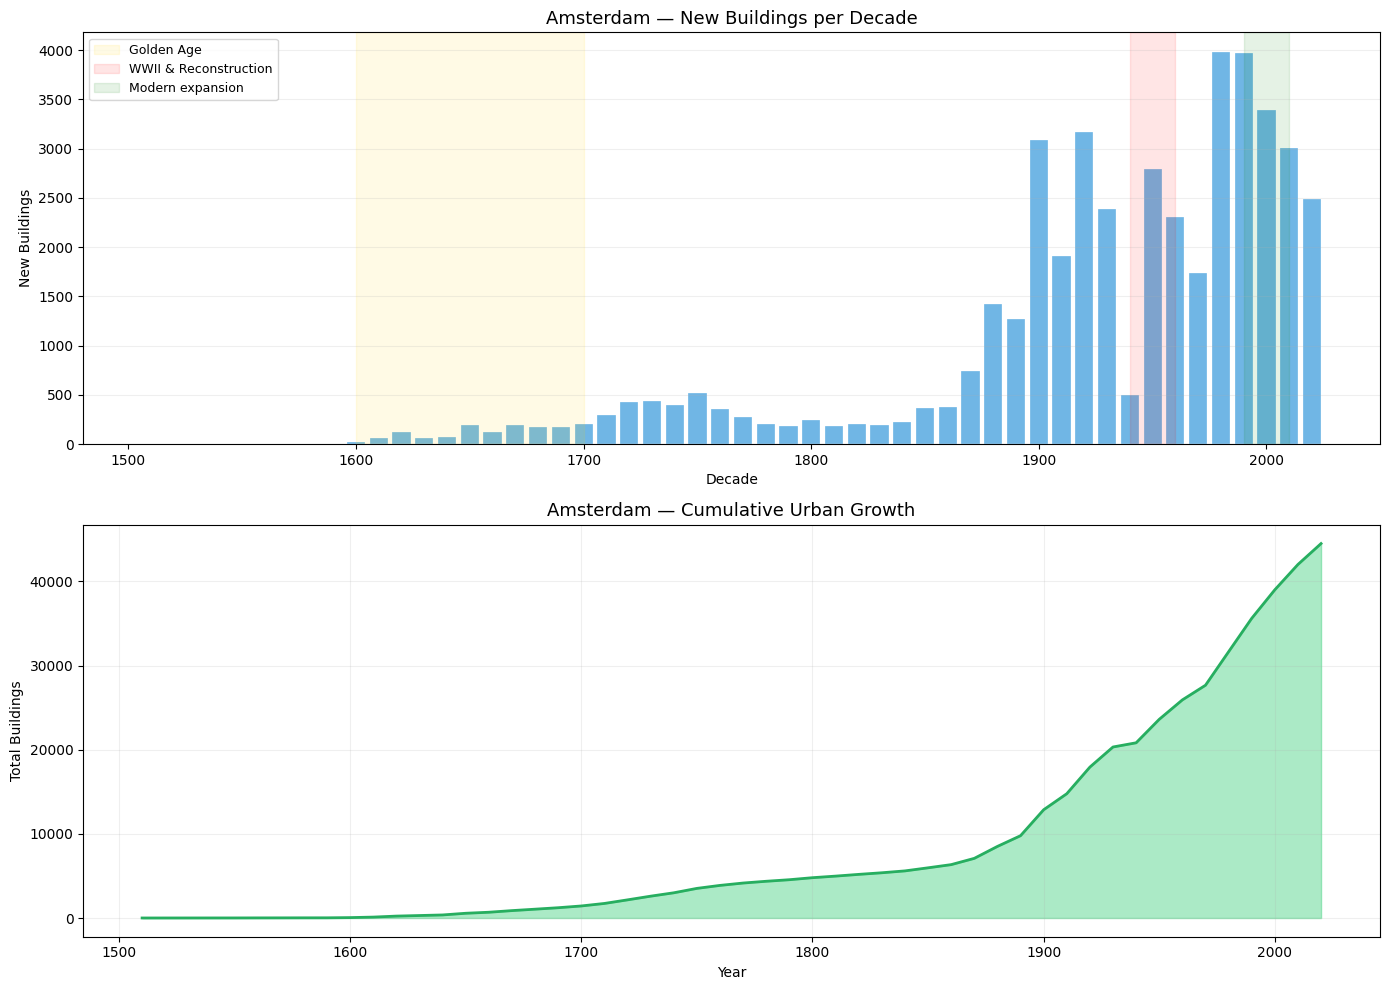

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Grafico 1 — Nuovi edifici per decennio
ax1.bar(edifici_per_decennio['Decennio'], 
        edifici_per_decennio['Nuovi_edifici'],
        width=8, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.3)

ax1.set_title('Amsterdam — New Buildings per Decade', fontsize=13)
ax1.set_xlabel('Decade')
ax1.set_ylabel('New Buildings')
ax1.grid(True, alpha=0.2, axis='y')

# Evidenziamo i periodi storici chiave
ax1.axvspan(1600, 1700, alpha=0.1, color='gold', label='Golden Age')
ax1.axvspan(1940, 1960, alpha=0.1, color='red', label='WWII & Reconstruction')
ax1.axvspan(1990, 2010, alpha=0.1, color='green', label='Modern expansion')
ax1.legend(fontsize=9)

# Grafico 2 — Crescita cumulativa
ax2.fill_between(edifici_per_decennio['Decennio'],
                 edifici_per_decennio['Totale_cumulativo'],
                 alpha=0.4, color='#2ecc71')
ax2.plot(edifici_per_decennio['Decennio'],
         edifici_per_decennio['Totale_cumulativo'],
         color='#27ae60', linewidth=2)

ax2.set_title('Amsterdam — Cumulative Urban Growth', fontsize=13)
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Buildings')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('amsterdam_urban_growth.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Aggiungiamo lo Stadsdeel agli edifici
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
gdf_clean = gdf_clean.to_crs(buurten.crs)

joined = gpd.sjoin(gdf_clean, buurten[['Stadsdeel', 'geometry']], 
                   how='left', predicate='within')

# Raggruppiamo per decennio e Stadsdeel
growth_stadsdeel = joined.groupby(['Decennio', 'Stadsdeel']).size().reset_index()
growth_stadsdeel.columns = ['Decennio', 'Stadsdeel', 'Nuovi_edifici']

# Teniamo solo i Stadsdeel principali
principali = ['Centrum', 'West', 'Zuid', 'Oost', 'Noord', 'Nieuw-West', 'Zuidoost']
growth_filter = growth_stadsdeel[growth_stadsdeel['Stadsdeel'].isin(principali)]

print(growth_filter.head(15))

    Decennio Stadsdeel  Nuovi_edifici
0       1510   Centrum              2
1       1550   Centrum              5
3       1560   Centrum              4
5       1570   Centrum              3
6       1580   Centrum              4
7       1590   Centrum              2
8       1600   Centrum             24
9       1600     Noord              1
11      1610   Centrum             60
12      1620   Centrum            114
14      1630   Centrum             65
16      1630      West              1
17      1640   Centrum             69
18      1650   Centrum            180
19      1650     Noord              1


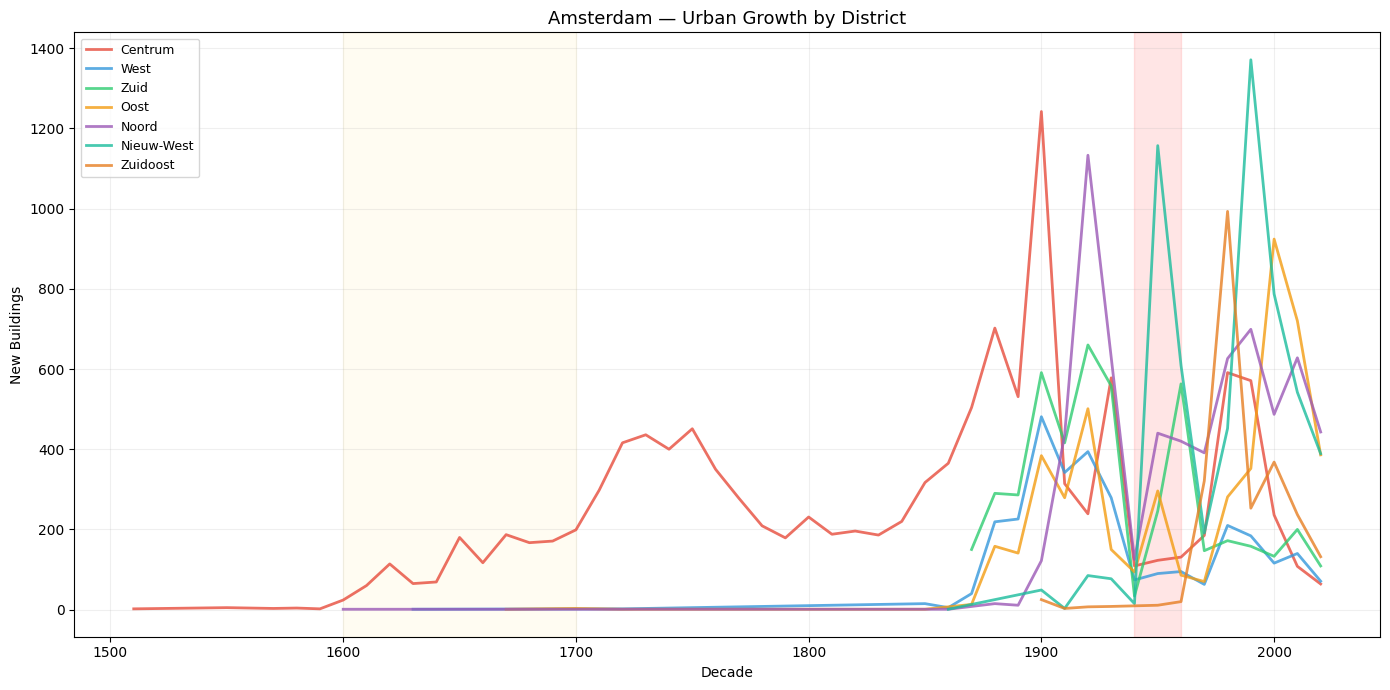

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

colori = {
    'Centrum': '#e74c3c',
    'West': '#3498db',
    'Zuid': '#2ecc71',
    'Oost': '#f39c12',
    'Noord': '#9b59b6',
    'Nieuw-West': '#1abc9c',
    'Zuidoost': '#e67e22'
}

for stadsdeel in principali:
    dati = growth_filter[growth_filter['Stadsdeel'] == stadsdeel]
    ax.plot(dati['Decennio'], dati['Nuovi_edifici'],
            label=stadsdeel, color=colori[stadsdeel],
            linewidth=2, alpha=0.8)

ax.set_title('Amsterdam — Urban Growth by District', fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('New Buildings')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)

# Periodo storico
ax.axvspan(1600, 1700, alpha=0.05, color='gold')
ax.axvspan(1940, 1960, alpha=0.1, color='red')

plt.tight_layout()
plt.savefig('amsterdam_growth_districts.png', dpi=150, bbox_inches='tight')
plt.show()